---
title: Week 4.2, Real world Application, Simulation of Travertine formation
subtitle: Orchestra Scenario, Lorah & Herman
author:
  - name: Timo Heimovaara
    affiliations: Delft University of Technology, department of Geoscience & Engineering
    orcid: 
    email: t.j.heimovaara@tudelft.nl
license: CC-BY-NC-ND-4.0 (https://creativecommons.org/licenses/by-nc-nd/4.0/).
date: 2026-01-30
kernelspec:
    name: python3
    display_name: 'Python 3.13'
---

In [1]:
# Import libraries required for running all simulations
import locale
# locale.setlocale(locale.LC_ALL, 'en_US.UTF-8') # for formatting numbers with commas
locale.setlocale(locale.LC_ALL, 'C') # 

import os
import sys
from IPython.utils import capture
from IPython.display import display, Markdown
from pathlib import Path
from contextlib import chdir

import numpy as np
import matplotlib.pyplot as plt
import PyORCHESTRA # here, the ORCHESTRA submodule is imported
import pandas as pd
import seaborn as sns

%matplotlib widget
sns.set()

# Prepare a file to capture PyOrchestra output
capture_file = open("pyorchestra_output.log", "w")


# pyOrchestra is implemented in C++
# Save original stdout file descriptor
# original_stdout_fd = sys.stdout.fileno()

# Duplicate original stdout so we can restore it later
# saved_stdout_fd = os.dup(original_stdout_fd)



# We need to import some Orchestra files. We need to know the path layout on 
# the local machine:
def find_book_root(start: Path | None = None) -> Path:
    """
    Walk upward from `start` (or CWD) until a directory containing Jupyter Book
    marker files is found. Returns the path to the book root.
    Raises FileNotFoundError if no root is found.
    """
    config_any = {"_config.yml", "_config.yaml"}      # some projectrs use .yaml
    myst_any = {"myst.yml", "myst.yaml"}            # jupyter-book uses _toc.yml

    cur = Path(Path.cwd()).resolve()

    for parent in [cur, *cur.parents]:
        children = {f.name for f in parent.iterdir()} if parent.exists() else set()
        has_any_config = bool(config_any & children)
        has_any_myst = bool(myst_any & children)
        if has_any_config and has_any_myst:
            return parent

    raise FileNotFoundError(
        f"Could not find Jupyter Book root (no _config.y* and myst.y* found above {cur})"
    )


def path_from_book_root(*parts: str | Path) -> Path:
    root = find_book_root()
    p = (root.joinpath(*parts)).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Path not found: {p}")
    return p

# In order for orchestra to run we need to change directory to the directory with the input file:


# Example usage:
# input_file = path_from_book_root("content", "week 02", "Orchestra_simulation", "chemistry1.inp")
# print("Input file:", input_file)

orchestra_path = path_from_book_root("content", "project_THe", "Travertine_Example_Tutorial","Travertine_Orchestra")
# print(orchestra_path)

## Unravelling the geochemistry of Travertine deposition along a stream
The data for this exercise are taken from:
**Reference:** Lorah, M.M. & Herman J.S. (1988) – *The chemical evolution of a travertine-depositing stream: Geochemical processes and mass transfer reactions*  
<https://doi-org.tudelft.idm.oclc.org/10.1029/WR024i009p01541>  

In the paper by Lorah and Herman (1988) you will see that several sampling trips were made to collect samples along a stream moving away from the hot springs where the stream originates, past a waterfall and then further down stream. In Table 1, some analysis results are presented for to sampling campaigns, one on 14 October 1984 and another on 6  April 1985. We will use these data for our analysis.

The aim of the analysis is to increase our understanding of the formation of travertine deposits along the stream and especially near the water fall. The analysis is similar to described in the paper.

The analysis consists in principle of two main steps:
1. We use the analysis results from the table to assess the the most likely in-situ conditions at the moment of sampling. The analysis results, give totals of the elements in mg/L. The true speciation will vary, elements will be present in other forms as well, solid minerals may control the composition of the water, but are not sampled with the water. The system may, or may not be in equilibrium. We analyze this problem with Orchestra using an Chemistry input file where we give the total of all measured compounds as master species, and we do not allow any minerals to precipitate, but we do report the SI-values for those minerals.
2. After doing the first analysis, we have additional information compared to the chemical analysis results from the lab, we know partial $\text{CO}_2\text{[g]}$ pressure and the SI-values for possible minerals for the water samples along the river. It is safe to assume that water down stream from the spring originated from the spring and that its composition should be related to the water at the spring. With this assumption we can use Orchestra to simulate changes related to the measurements obtained above. For example: if we have water from S-1 and move this to the conditions at F-6 ($\text{CO}_2[g]$ pressure and Calcite-SI), how much calcite would have precipitated in between?

```{figure} ./GIS/map_for_report.png
:label: Map from paper
:align: center
:width: 100%
Figure 1: Map from the paper projected on OpenStreetMap.
```

In Orchestra you define the type of calculation you want to do with a *chemistry.inp* file. For this assignment we need two types:
1. To calculate the equilibrium calculations for our system without allowing minerals to precipitate;
2. As similar input file, but where we allow the minerals to precipitate. As we want to compare samples along the river, we also need to be able to control the SI-value which is used to achieve the equilibrium. Normally, the SI-value is assumed to be zero for a sample in equilibrium, however, in this assignment we need to allow the model to equilibrate assuming higher, or even lower SI-values. This we achieve by manually adding a constant to the equilibrium equation in the *chemistry.inp* file. In addition, the $\text{CO}_2\text{[g]}$ pressure needs to be fixed as well, which we can achieve by fixing the CO2[g].logact.

### Extracting the coordinates of the measurement points
Because we have georeferenced the map from the paper to the OpenStreetMap using QGIS we can extract the x and y coordinates from the map. In addition we used QGIS to calculate the distance along the stream from the source. We can import these data so that we can plot the calculated results along the distance. 


In [2]:
# Add extracted coordinates and length along Falling Spring Creek to a dataframe for later processing
coord_dict = {
    'S-1': [-79.9333752265005586, 37.86960346907188324,	0],
    'S-2': [-79.93378630600923884, 37.86936810963599953, 0.113],
    'S-3': [-79.93358754229075203, 37.86943586470219003, 0.061],
    'D-1': [-79.93435549302124343, 37.86930035450750154, 0.256],
    'D-2': [-79.93524992975443411, 37.86967835600746213, 0.484],
    'D-3': [-79.93543965875844037, 37.86937524175117176, 0.529],
    'F-1': [-79.94694933545359561, 37.86809462323325448, 3.585],
    'F-2': [-79.95186467914058426, 37.87099898234640705, 5.228],
    'F-3': [-79.94752328277034792, 37.8677809455992076,	 3.748],
    'F-4': [-79.94783233132551459, 37.86774609244633893, 3.823],
    'F-5': [-79.94981907203731453, 37.86894270792835471, 4.419],
    'F-6': [-79.95239447666375554, 37.87369412518480516, 5.954],
}

df_coord = pd.DataFrame(data=coord_dict, index =['x-coord', 'y_coord', 'distance']).T

df_coord

,x-coord,y_coord,distance
S-1,-79.933375,37.869603,0.000
S-2,-79.933786,37.869368,0.113
S-3,-79.933588,37.869436,0.061
D-1,-79.934355,37.869300,0.256
D-2,-79.935250,37.869678,0.484
D-3,-79.935440,37.869375,0.529
F-1,-79.946949,37.868095,3.585
F-2,-79.951865,37.870999,5.228
F-3,-79.947523,37.867781,3.748
F-4,-79.947832,37.867746,3.823


## Step 1: Assessing the water samples
For this first step we have prepared an Orchestra input file using the *orchestra2026.jar* Graphical User Interface (GUI). Please have a look at this file with the GUI. 
The approach was quite simple, we added all the analysed compounds that are found in the table as primary entities in the dissolved phase (*diss*). We define the pH as a fixed logact and we assume that water is the solute phase with a fixed logactivity of 0. We make sure that none of the mineral phases on the *Phases & Reactions* tab are selected, because we do not allow for any precipitation. We assume that the water samples are stored in bottles with out any gas-phase (head space), we set the gasvolume to be zero on the *Variables* tab. This chemical system is defined in *chemistry_Travertine.inp*.

In order to illustrate the steps, we will analyse two water samples: S1 and F1. Please note that the concentrations are given in $\text{mg/l}$ and the temperature in $^\text{o}\text{C}$, we need to translate these numbers to $\text{mol/l}$ and $\text{K}$ in order to work with Orchestra.

```{hint} Creating the *chemistry.inp* file
Using the Orchestra GUI shown in [](#master_species)  we are able to define a system of the primary entities. You do this by selecting the **Chemistry** tab on the right in the ORCHESTRA-COMPOSER window. The **Chemistry** tab shows a number of tabs which fill the *chemistry1.inp* file. We start by selecting tab **Primary entities/ Master Species**. Remember that the Master Species you select will be used to create all other species in the system using the mass-action laws. The interface in principle will not allow you to select to master species for the same component. The Master species are used to define the total moles present in the system (including the amounts of these master species present in the dervied dissolved, solids and gaseous species).
```


In [3]:
# copy data from Lorah and Herman (1988)
# We store the data in a data frame
# Because the data are given in mg/L we need the molar masses to be able to 
# translate to mol/liter

# for conveniece we set mmass for non chemical values to 0.001 because it is then very easy
# to calculate the concentrations in mol per liter...
# Please note: we use Orchestra notation

headers = ['Sample','T_celsius', 'Conductivity', 'pH', 'HCO3-.tot', 'Ca+2.tot',  
           'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot']
data = [
       ['mmass', 1e-3, 1e-3, 1e-3, 1.00794 + 12.0107 + 3*15.9994, 40.078, 24.305, 
         22.9898, 39.0983, 18.9984, 35.453, 32.065 + 4*15.9994],
       ['S-1', 24.3, 700, 7.32, 308, 165, 25.4, 5.1, 14.2,  1.0, 3.3, 283.],
       ['F-6', 14.4, 442, 8.25, 210, 122, 21.3, 3.3, 11.4, 0.7, 4, 246]
    ]
df_data_orig = pd.DataFrame(data=data,columns=headers)
df_data_orig.set_index('Sample',inplace=True)

# calculate molar concentrations
df_data = pd.DataFrame()
df_data = df_data_orig.loc[['S-1','F-6']]/df_data_orig.loc['mmass'] * 0.001
# calculate temperature in K
df_data['T'] = df_data['T_celsius'] + 273.15

# table_md_data = df_data.to_markdown(floatfmt='.4e')
# display(Markdown(table_md_data))
df_data

,T_celsius,Conductivity,pH,HCO3-.tot,Ca+2.tot,Mg+2.tot,Na+.tot,K+.tot,F-.tot,Cl-.tot,SO4-2.tot,T
Sample,,,,,,,,,,,,
S-1,24.3,700.0,7.32,0.005048,0.004117,0.001045,0.000222,0.000363,0.000053,0.000093,0.002946,297.45
F-6,14.4,442.0,8.25,0.003442,0.003044,0.000876,0.000144,0.000292,0.000037,0.000113,0.002561,287.55


## Initialise the problem 
In order solve this problem with pyOrchestra we first initialize our problem using the *chemistry_Travertine.inp* file. 
This file predefines the aqueous chemical system in such a way that we can use the information from the tables in the paper as inputs to the Orchestra simulation.

Once pyOrchestra is initialized, running a simulation consists of a series of steps where the values of the required set of input variables are passed via *InVARS* to ORCHESTRA, after which a set of corresponding output variables are passed back in *OutVars*.

ORCHESTRA is initialized in pyOrchestra using the inputfile *chemistry_Travertine.inp*, created above with the ORCHESTRA-GUI. 

The *InVars* are all master species and any other constant in the model which we would like to change during the simulation. In this example we include the following constants defined in the *chemistry_Travertine.inp* file: *watervolume*, *gasvolume*, *fixed_logact_CO2* and *deltaSIcalcite*.

Each calculation in ORCHESTRA will result in a wide range of chemical species and other parameters. Using the *Output selector* tab in the GUI we can quickly select the required output. We have copied this list to this notebook so our simulations have access to all possible outputs from ORCHESTRA.

### Types of ouput from pyOrchestra
Orchestra makes use of a phase hierarchy to maintain the mass-balance. This phase hierarchy can be used to extract relevant parameters from the output as well.
- _{species}.tot_ provide the total amount of the species in the system (i.e. over the dissolved, solid and gas_phases. For the master-species the total is summed over all species based on the master-species;
- _{species}.logact_ provide the logactivities of the species, in the respective phase where the species is present.
- _{species}.con_ gives the molar concentration of species in the dissolved phase or the partial gas pressure for species in the gas phase
- _{species}.si_ gives that saturation index (SI) of the mineral phase. Negative values indicate sub-saturation, positive values indicate super-saturation. If the mineral is allowed to precipitate when the SI is positive, _{species}.si_ = 0 ans {species}.tot will be larger than 0 as minerals due to precipitation. 
- _{species}.diss_, _{species}.gas_, _{species}.min_ each give the total of the species integrated over the respective phase. For the master-species, all derived sub-species are included in the total.




In [4]:
# Define lists for inputs and outputs from pyOrchestra
inputs = [
    'pH', 'HCO3-.tot', 'Ca+2.tot', 'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot', 
    'T', 'watervolume', 'gasvolume_fixed',
    'fixed_logact_CO2', 'deltaSIcalcite'
]

#outputs
outputs_logact = [
    'Alkalinity.logact','Ar.logact','Ar[g].logact','C.logact','CO2.logact','CO2[g].logact','CO3-2.logact',
    'C[+4].logact','Ca.logact','Ca+2.logact','CaCO3.logact','CaF+.logact','CaHCO3+.logact','CaHSO4+.logact',
    'CaOH+.logact','CaSO4.logact','Cl.logact','Cl-.logact','F.logact','F-.logact','H.logact','H+.logact',
    'H2CO3.logact','H2F2.logact','H2O.logact','H2O[g].logact','HCO3-.logact','HF.logact','HF2-.logact',
    'HSO4-.logact','H[+1].logact','K.logact','K+.logact','KSO4-.logact','Mg.logact','Mg+2.logact','MgCO3.logact',
    'MgF+.logact','MgHCO3+.logact','MgOH+.logact','MgSO4.logact','Na.logact','Na+.logact','NaCO3-.logact','NaF.logact',
    'NaHCO3.logact','NaSO4-.logact','O.logact','OH-.logact','O[-2].logact','S.logact','SO4-2.logact','S[+6].logact',
]

outputs_con = [
    'Alkalinity.con','Ar.con','Ar[g].con','C.con','CO2.con','CO2[g].con','CO3-2.con',
    'C[+4].con','Ca.con','Ca+2.con','CaCO3.con','CaF+.con','CaHCO3+.con','CaHSO4+.con',
    'CaOH+.con','CaSO4.con','Cl.con','Cl-.con','F.con','F-.con','H.con','H+.con',
    'H2CO3.con','H2F2.con','H2O.con','H2O[g].con','HCO3-.con','HF.con','HF2-.con',
    'HSO4-.con','H[+1].con','K.con','K+.con','KSO4-.con','Mg.con','Mg+2.con','MgCO3.con',
    'MgF+.con','MgHCO3+.con','MgOH+.con','MgSO4.con','Na.con','Na+.con','NaCO3-.con','NaF.con',
    'NaHCO3.con','NaSO4-.con','O.con','OH-.con','O[-2].con','S.con','SO4-2.con','S[+6].con',
]

outputs_min_si = [
    'Anhydrite[s].si','Aragonite[s].si','Artinite[s].si','Brucite[s].si','CO2g[s].si','Calcite[s].si',
    'Dolomite[d][s].si','Dolomite[s].si','Epsomite[s].si','Fluorite[s].si','Gypsum[s].si','Halite[s].si',
    'Huntite[s].si','Hydromagnesite[s].si', 'Magnesite[s].si','Mirabilite[s].si','Nahcolite[s].si',
    'Natron[s].si','Nesquehonite[s].si','Portlandite[s].si','Thenardite[s].si','Thermonatrite[s].si',
    'Trona[s].si',
]

outputs_min_tot = [
    'Anhydrite[s].tot','Aragonite[s].tot','Artinite[s].tot','Brucite[s].tot','CO2g[s].tot','Calcite[s].tot',
    'Dolomite[d][s].tot','Dolomite[s].tot','Epsomite[s].tot','Fluorite[s].tot','Gypsum[s].tot','Halite[s].tot',
    'Huntite[s].tot','Hydromagnesite[s].tot', 'Magnesite[s].tot','Mirabilite[s].tot','Nahcolite[s].tot',
    'Natron[s].tot','Nesquehonite[s].tot','Portlandite[s].tot','Thenardite[s].tot','Thermonatrite[s].tot',
    'Trona[s].tot',
]

outputs_extra = [
    'chargebalance', 'totcharge', 'I',
]

outputs_master_diss = [  
    'HCO3-.diss', 'Ca+2.diss', 'Mg+2.diss', 'Na+.diss', 'K+.diss', 'F-.diss', 'Cl-.diss', 'SO4-2.diss'
]

### The constants *fixed_logact_CO2* and *deltaSIcalcite*
The constants *fixed_logact_CO2* and *deltaSIcalcite* are specific for this problem and are used to allow the user to be able to control the equilibrium value for specific simulations.

The *fixed-logact_CO2* is based on a *trick* where we create a virtual solid phase *CO2g[s]* which is controlled by *fixed_logact_CO2*. If the CO2[g].logact exceeds *fixed_logact_CO2*, *CO2g[s]* will precipitate and function as a reservoir to provide sufficient CO2[g] to the system to allow equilibrium to be achieved. The excess of CO2[g] is provided through the value of the HCO3-.tot value.

### Code for initialization of the non-precipitating system

In [5]:
#--- Initialize problem --- 
# for initialization we need to temporarily move to the directory containing the 'chemistry1.inp' file.
# Later we use pO1, InVars1 and OutVars1
with chdir(orchestra_path):

    # Input file is generated with Orchestra GUI
    InputFile = 'chemistry_Travertine.inp'
    NoCells = 1 #only 1 cell to have a 0-D system with 1liter of water
    
    # We define the input variables that will be changed in the script
    # We use the same sequence as used in the paper
    InVars1 = np.array(inputs)
    
    # We select the output from Orchestra we need to use
    outlist = (outputs_logact + outputs_con +
        outputs_min_si + outputs_min_tot + outputs_master_diss +
        inputs + outputs_extra)

    OutVars1 = np.array(outlist)

    # Associate a variable with the pyOrchestra.ORCHESTRA() class
    pO1 = PyORCHESTRA.ORCHESTRA()

    # Initialize the class with the parameters defined above
    pO1.initialise(InputFile, NoCells, InVars1, OutVars1)


Reading and expanding calculator new stylechemistry_Travertine.inp
Scanning file: chemistry_Travertine.inp
Scanning file: objects2026_THe.txt
Scanning file: chemistry_Travertine.inp
Scanning file: objects2026_THe.txt
Including file: chemistry_Travertine.inp
Scanning file: objects2026_THe.txt
0.059 sec.
	Reading variables .... 0.028 s
testing:
14:pH
16:HCO3-.tot
9:Ca+2.tot
20:Mg+2.tot
22:Na+.tot
18:K+.tot
13:F-.tot
11:Cl-.tot
24:SO4-2.tot
25:T
26:watervolume
27:gasvolume_fixed
28:fixed_logact_CO2
29:deltaSIcalcite
30:Alkalinity.logact
31:Ar.logact
7:Ar[g].logact
32:C.logact
33:CO2.logact
34:CO2[g].logact
35:CO3-2.logact
36:C[+4].logact
37:Ca.logact
8:Ca+2.logact
38:CaCO3.logact
39:CaF+.logact
40:CaHCO3+.logact
41:CaHSO4+.logact
42:CaOH+.logact
43:CaSO4.logact
44:Cl.logact
10:Cl-.logact
45:F.logact
12:F-.logact
46:H.logact
47:H+.logact
48:H2CO3.logact
49:H2F2.logact
2:H2O.logact
50:H2O[g].logact
15:HCO3-.logact
51:HF.logact
52:HF2-.logact
53:HSO4-.logact
54:H[+1].logact
55:K.logact
17:K+

Please note that the output of this code is what ORCHESTRA echos back. ORCHESTRA uses a set of variables in order to store the input variables and the results of the calculations, in this case 179. The top part of the output shows the master species and the output requested by us through *OutVars* together with the values used during initialization.

## Calculate the speciation assuming no precipitation
We analyse the two water samples we imported above: S1 and F6. We have already translated to mol/l and K in order to work with Orchestra.



In [6]:
# %%
# Run the model using chemistry_Travertine.inp for the above samples

# Initialize the pyOrchestra Input array can create a OrchInput data frame 
# for easy evaluation
IN1 = np.array([np.ones_like(InVars1)]).astype(float)
OrchInput = pd.DataFrame(columns=InVars1, index=df_data.index)

# Initialize Res_Simulation dataframe to capture the pyOrchestra output using OutVars1
Res_Simulation = pd.DataFrame(columns=OutVars1, index=df_data.index)

# set default constants
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = 0.0 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samples in df_data
for sample in df_data.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -4, constants have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO1.set_and_calculate(IN1)

    # Store input and output in dataframes
    OrchInput.loc[sample] = IN1[0]    
    Res_Simulation.loc[sample] = OUT[0]

# Print a summary of the output in order to do first check on the results
Res_List = [
    'pH','T', 'I','HCO3-.tot',
    'Ca+2.tot', 'HCO3-.con', 'Ca+2.con', 'HCO3-.diss', 'Ca+2.diss',
    'CO2[g].con','CO2[g].logact','Calcite[s].si','Calcite[s].tot']

table_mdini = Res_Simulation[Res_List].to_markdown(floatfmt='.4e')

# display(Markdown(table_mdini))
Res_Simulation[Res_List]

,pH,T,I,HCO3-.tot,Ca+2.tot,HCO3-.con,Ca+2.con,HCO3-.diss,Ca+2.diss,CO2[g].con,CO2[g].logact,Calcite[s].si,Calcite[s].tot
Sample,,,,,,,,,,,,,
S-1,7.32,297.450012,0.013955,0.005048,0.004117,0.00122,0.003418,0.001516,0.004117,0.00339,-2.469777,-0.174844,0.0
F-6,8.25,287.549988,0.012219,0.003442,0.003044,0.002506,0.002523,0.002699,0.003044,0.000712,-3.147332,0.817505,0.0


In [7]:
OrchInput

,pH,HCO3-.tot,Ca+2.tot,Mg+2.tot,Na+.tot,K+.tot,F-.tot,Cl-.tot,SO4-2.tot,T,watervolume,gasvolume_fixed,fixed_logact_CO2,deltaSIcalcite
Sample,,,,,,,,,,,,,,
S-1,7.32,0.005048,0.004117,0.001045,0.000222,0.000363,0.000053,0.000093,0.002946,297.45,1.0,1.0,0.0,0.0
F-6,8.25,0.003442,0.003044,0.000876,0.000144,0.000292,0.000037,0.000113,0.002561,287.55,1.0,1.0,0.0,0.0


## Interpretation of the results
The results clearly show that the water samples are not in equilibrium with the atmosphere and calcite. The partial pressure of $\text{CO}_2[g]$ is about 400 ppm which would be 0.0004 at which is lower that calculated above. In addition the SI for calcite is above zero.

What is also striking to see is that the SI for calcite increases along the stream, the CO2[g].logact decreases along the stream and we know that Calcite is precipitating from the stream. How much calcite will have precipitated moving from S-1 to F-6?

In [8]:
# Calculate the Electrical Balance in % from the results
EB = Res_Simulation['chargebalance']/Res_Simulation['totcharge'] * 100

print(f"The chargebalances of the simulated solution are {Res_Simulation['chargebalance'].values} and the total charge in the system is {Res_Simulation['totcharge'].values}. ")
print(f"The electrical balance is therefore {EB.values} %. ")

The chargebalances of the simulated solution are [0.0035858191549777985 0.0003099597233813256] and the total charge in the system is [0.013673934154212475 0.02489149011671543]. 
The electrical balance is therefore [26.223756195821153 1.2452437436567036] %. 


When you calculate the charge balance of the sample using the master species only, we get an electrical balance of -0.8 and 2.6 % for S-1 and F-6. However as you can see above the charge balance of the simulated values change. The reason for this is that many sub-species are present in the simulation which have a different charge than the master-species itself. This is the reason why for example Ca+2.tot is different from Ca+2.con. For both samples Ca+2.con is about 82% of the Ca+2.tot.

This is clearly seen when we have a look at the all dissolved species derived from Ca+2. There are potentially many more species in solution than only Ca+2.:

In [9]:
print(f"The ratios of Ca+2.con to Ca+2.tot are: \n{Res_Simulation['Ca+2.con']/Res_Simulation['Ca+2.tot'].values}") 


sel_CaCon = (
    (Res_Simulation.columns.str.contains('.con')) &
    (Res_Simulation.columns.str.contains('Ca'))
)
CaCon_list = Res_Simulation.columns[sel_CaCon]
# Display the results in a nice output format
# display(Markdown(Res_Simulation[CaCon_list].to_markdown(floatfmt='.4e')))

Res_Simulation[CaCon_list]

The ratios of Ca+2.con to Ca+2.tot are: 
Sample
S-1     0.83011
F-6    0.828972
Name: Ca+2.con, dtype: object


,Ca.con,Ca+2.con,CaCO3.con,CaF+.con,CaHCO3+.con,CaHSO4+.con,CaOH+.con,CaSO4.con
Sample,,,,,,,,
S-1,0.0,0.003418,0.000003,0.000001,0.000047,0.0,0.0,0.000648
F-6,0.0,0.002523,0.000031,0.0,0.000056,0.0,0.0,0.000433


## Check for equilibrium in the sample
We can check the output for minerals that are close to saturatin or super saturated. We do this by selecting all minerals in the data set where the SI is > -0.1.

In [10]:
# List all minerals with SI-values > -0.1

sel_large_SI = (
    (Res_Simulation.loc['S-1', outputs_min_si] > -0.1) |
    (Res_Simulation.loc['F-6', outputs_min_si] > -0.1) 
)

# Display the results in a nice output format
selected_minerals = sel_large_SI[sel_large_SI].index.tolist()
# display(Markdown(Res_Simulation[selected_minerals].to_markdown(floatfmt='.4e')))

Res_Simulation[selected_minerals]

,Aragonite[s].si,Calcite[s].si,Dolomite[d][s].si,Dolomite[s].si
Sample,,,,
S-1,-0.356508,-0.174844,-1.362199,-0.809314
F-6,0.611659,0.817505,0.493487,1.088212


Clearly both samples are in a non-equilibrium state as they are supersaturated for a number of carbonate minerals based on Ca+2 and Mg+2. Calcite[s] is the mineral with the highest SI-value. If we would allow Calcite to precipitate, most likely all the other carbonate minerals would also be sub-saturated, i.e. would not be able to form.

Dolomites are not often found in precipitates from water samples as the mineralization of Dolomite is a very slow process, especially when you compare that with Calcite or Aragonite.

## Simulation #1: Calculate amount of calcite precipitated along stream from S-1 to F-6
In order to run this scenario, we need a different type of calculation than used for step 1. The main difference is that we need to allow Orchestra to precipitate calcite in order to reach equilibrium. We need to activate the precipitation reactions in the GUI, which allows Orchestra to add the reactions to the equation set and equilibrium is reached by allowing the mineral to form when the SI is larger than 0. 

In addition to allowing Calcite to precipitate, we also want to be able to adjust the SI value to control the equilibrium condition of Calcite. We can achieve this by adding a constant to the precipitation reaction of Calcite in the *chemistry_Travertine_fixed_CO2_logact.inp* file. In this case we added *deltaSIcalcite* and *fixed_logact_CO2* to the file, both with a default value of 0. If we set to another value, the model solves an equilibrium for this other value. 

Another very important change is that we also nee to allow Orchestra to achieve mass balance using the pH (i.e. by adding protons or hydroxyl ions).

We can now initialise a second Orchestra calculator for this input file using the same inputs and outputs.

In [11]:
#--- Initialize problem --- 
# for initialization we need to temporarily move to the directory containing the 'chemistry2.inp' file.
# Later we use pO2, InVars2 and OutVars2
with chdir(orchestra_path):

    # Input file is generated with Orchestra GUI
    InputFile = 'chemistry_Travertine_fixed_CO2_logact.inp'
    NoCells = 1 #only 1 cell to have a 0-D system with 1liter of water
    
    # We define the input variables that will be changed in the script
    # We use the same sequence as used in the paper
    InVars2 = np.array(inputs)
    
    OutVars2 = np.array(outlist)

    # Associate a variable with the pyOrchestra.ORCHESTRA() class
    pO2 = PyORCHESTRA.ORCHESTRA()

    # Initialize the class with the parameters defined above','
    pO2.initialise(InputFile, NoCells, InVars2, OutVars2)

Try a first calculation with iia switched off....
Parsing expressions of chemistry_Travertine.inp..... 
Optimizing expressions of chemistry_Travertine.inp..... 0.151 sec.
3848 variables, 11090 expressions, 10 equations.
First calculation was successful!
Repeat calculation with iia switched on..
Switching on: logI: -2
This was successful!!
Reading and expanding calculator new stylechemistry_Travertine_fixed_CO2_logact.inp
Scanning file: chemistry_Travertine_fixed_CO2_logact.inp
Scanning file: objects2026_THe.txt
Scanning file: chemistry_Travertine_fixed_CO2_logact.inp
Scanning file: objects2026_THe.txt
Including file: chemistry_Travertine_fixed_CO2_logact.inp
Scanning file: objects2026_THe.txt
0.054 sec.
	Reading variables .... 0.031 s
testing:
15:pH
17:HCO3-.tot
10:Ca+2.tot
21:Mg+2.tot
23:Na+.tot
19:K+.tot
14:F-.tot
12:Cl-.tot
25:SO4-2.tot
28:T
29:watervolume
30:gasvolume_fixed
31:fixed_logact_CO2
32:deltaSIcalcite
33:Alkalinity.logact
34:Ar.logact
8:Ar[g].logact
35:C.logact
36:CO2.log

### Strategy to solve the problem
After initializing the Orchestra Calculator, we can solve the problem using our standard approach:
1. *Define the initial conditions:* The initial condition is determined by the measured (total) concentrations in the water sample at S-1 and the equilibrium state calculated above stored in *Res_Simulation*.
2. *Define the boundary conditions:* This is the crucial step for the scenario. The sample at F-6 clearly is in a different condition that S-1. The SI value for calcite is different, the CO2-pressure (CO2[g].con, or CO2[g].logact) is different and finally so is the temperature. We can set these conditions using the InVars2 array, where we use the masses from S-1 and  T, CO2[g].logact and SI Calcite from F-6 all estimated in the previous calculation. The SI-Calcite calculated for F-6 is used for the deltaSIcalcite variable.

We only carry out one additional simulation.

In [12]:
# Step 1, initial condition.
# InVars need to contain floats
# IN2 = np.array([np.ones_like(InVars2)]).astype(float)
IN2 = IN1

# set default watervolume and gasvolume
IN2[0][np.where(InVars2 == 'watervolume')] = 1.0 # per liter
IN2[0][np.where(InVars2 == 'gasvolume_fixed')] = 0.0 # no gas 

# Set the initial amounts of the master species to sample S-1
IN2[0][:-5] = df_data.loc['S-1', InVars2[:-5]].values

# Set the temperature, fixed_logact_CO2 and deltaSIcalcite values to the values at F-6
# logact CO2 and SI calcite were calculated in previous calculation.
# We use the values at F-6 because we want to equilibrate the sample from S-1 to F-6, so we need to use the boundary conditions at F-6.
IN2[0][np.where(InVars2 == 'T')] = Res_Simulation.loc['F-6','T']
IN2[0][np.where(InVars2 == 'fixed_logact_CO2')] = Res_Simulation.loc['F-6','CO2[g].logact']
IN2[0][np.where(InVars2 == 'deltaSIcalcite')] = Res_Simulation.loc['F-6','Calcite[s].si']

# In order to allow Orchestra to match the fixed_logact of CO2 we need to add sufficient carbonate to 
# the system. This equivalent to the PHREEQC approach of adding 10 moles of the phase...
# All excess carbonate will be precipitated as a virtual mineral CO2g[s].
IN2[0][np.where(InVars2 == 'HCO3-.tot')] = 0.5

# Run Orchestra simulation to equilibrate the sample from S-1 to F-6
OUT = pO2.set_and_calculate(IN2)

# Define a label for the output index
simindex = 'S-1 to F-6'

OrchInput.loc[simindex] = IN2[0]    
Res_Simulation.loc[simindex] = OUT[0]

# Need to add the deltaSIcalcite value to the Calcite[s].si value in the output (Orchestra does not do this automatically)
Res_Simulation.loc[simindex, 'Calcite[s].si'] += Res_Simulation.loc['F-6', 'Calcite[s].si']

print("Equilibrate sample from S-1 to F-6")
# print(Res_Sim2[['T','pH','Ca+2.con', 'HCO3-.con', 'CO2[g].con', 'Calcite[s].si', 'Calcite[s].tot', 'CO2[g].logact']])

table_mdini = Res_Simulation[Res_List].to_markdown(floatfmt='.4e')
# display(Markdown(table_mdini))

Res_Simulation[Res_List]

Equilibrate sample from S-1 to F-6


,pH,T,I,HCO3-.tot,Ca+2.tot,HCO3-.con,Ca+2.con,HCO3-.diss,Ca+2.diss,CO2[g].con,CO2[g].logact,Calcite[s].si,Calcite[s].tot
Sample,,,,,,,,,,,,,
S-1,7.32,297.450012,0.013955,0.005048,0.004117,0.00122,0.003418,0.001516,0.004117,0.00339,-2.469777,-0.174844,0.0
F-6,8.25,287.549988,0.012219,0.003442,0.003044,0.002506,0.002523,0.002699,0.003044,0.000712,-3.147332,0.817505,0.0
S-1 to F-6,8.260701,287.549988,0.01316,0.5,0.004117,0.002578,0.002506,0.002767,0.003066,0.000712,-3.147332,0.817505,0.001051


In [13]:
OrchInput

,pH,HCO3-.tot,Ca+2.tot,Mg+2.tot,Na+.tot,K+.tot,F-.tot,Cl-.tot,SO4-2.tot,T,watervolume,gasvolume_fixed,fixed_logact_CO2,deltaSIcalcite
Sample,,,,,,,,,,,,,,
S-1,7.32,0.005048,0.004117,0.001045,0.000222,0.000363,0.000053,0.000093,0.002946,297.45,1.0,1.0,0.0,0.0
F-6,8.25,0.003442,0.003044,0.000876,0.000144,0.000292,0.000037,0.000113,0.002561,287.55,1.0,1.0,0.0,0.0
S-1 to F-6,7.32,0.5,0.004117,0.001045,0.000222,0.000363,0.000053,0.000093,0.002946,287.549988,1.0,0.0,-3.147332,0.817505


## Analysis
In the simulation above we assume that we can obtain a water sample similar to F-6 from S-1 by changing the SI of calcite and ensuring the temperature and the partial pressure $\text{CO}_2 \text{[g]}$ similar to those of F-6. Clearly this is not completely true which becomes clear when we compare the pH and and the biocarbonate concentrations. 


# Extension Run model for all measurements in Lorah and Herman (1988)
Of course it is possible to do above calculations for all samples present in the paper. We illustrate this below.

To show the illustration we calculate the non-equilibrium state for the samples from 1984 and 1985. We plot some parameters as a function of the distance along the stream. Finally we equilibrate the samples with the CO2[g] pressure in the atmosphere and we allow Calcite[s] to equilibrate with a SI of 0. We plot the amount of Calcite that can (still) precipitate from the original samples. 


In [14]:
# copy data from Lorah and Herman (1988)
# We store the data in a data frame
# Because the data are given in mg/L we need the molar masses to be able to 
# translate to mol/liter

# for conveniece we set mmass for non chemical values to 0.001 because it is then very easy
# to calculate the concentrations in mol per liter...
# Please note: we use Orchestra notation

# Data October 14, 1984
# we save the molar mass data from earlier so we can still use it as we choose to overwrite data
headers = ['Sample', 'T_celsius', 'Conductivity', 'pH', 'HCO3-.tot', 'Ca+2.tot',
           'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot']
data = [ 
    ['S-1', 24.3, 700, 7.32, 308, 165, 25.4, 5.1, 14.2, 1, 3.3, 283],
    ['S-3', 24.6, 730, 7.23, 316,168,28,3.9,14.8,1.1,3.5,291], 
    ['S-2', 24.7, 720, 7.2, 315,169,26.2,3.9,14.3,1.1,5.8,296], 
    ['D-1', 24.3, 730, 7.24, 310,168,26,3.4,14.2,1.1,3.2,283], 
    ['D-3', 23.6, np.nan, 7.43, 314, 168, 26.2, 2.8, 12.9, 1.2, 3.5, 288], 
    ['F-1', 21.4, 695, 7.79, 312,166,25.6,3.5,13.9,1.2,3.4,286], 
    ['F-3', 20.5, 695, 8.06, 311,164,25.2,3.7,14,1,3.5,283], 
    ['F-4', 19.7, 690, 8.27, 278,160,25.6,3.6,14.3,1,3.8,286], 
    ['F-5', 19.6, 690, 8.28, 273,157,25.5,3.1,14,1.1,3.4,283], 
    ['F-2', 18.4, 660, 8.37, 264,151,25.6,3.2,14.3,1,3.4,283], 
    ['F-6', 14.4, 442, 8.25, 210,122,21.3,3.3,11.4,0.7,4,246] 
    ]


df_data_orig_1984 = pd.DataFrame(data=data,columns=headers)
df_data_orig_1984.set_index('Sample',inplace=True)

# calculate molar concentrations
#df_data_1984 = pd.DataFrame()
df_data_1984 = df_data_orig_1984/df_data_orig.loc['mmass'] * 0.001
# calculate temperature in K
df_data_1984['T'] = df_data_1984['T_celsius'] + 273.15

table_md_data = df_data_1984.to_markdown(floatfmt='.4e')
# display(Markdown(table_md_data))

df_data_1984
# print(df_data)

,T_celsius,Conductivity,pH,HCO3-.tot,Ca+2.tot,Mg+2.tot,Na+.tot,K+.tot,F-.tot,Cl-.tot,SO4-2.tot,T
Sample,,,,,,,,,,,,
S-1,24.3,700.0,7.32,0.005048,0.004117,0.001045,0.000222,0.000363,0.000053,0.000093,0.002946,297.45
S-3,24.6,730.0,7.23,0.005179,0.004192,0.001152,0.000170,0.000379,0.000058,0.000099,0.003029,297.75
S-2,24.7,720.0,7.20,0.005163,0.004217,0.001078,0.000170,0.000366,0.000058,0.000164,0.003081,297.85
D-1,24.3,730.0,7.24,0.005081,0.004192,0.001070,0.000148,0.000363,0.000058,0.000090,0.002946,297.45
D-3,23.6,NaN,7.43,0.005146,0.004192,0.001078,0.000122,0.000330,0.000063,0.000099,0.002998,296.75
F-1,21.4,695.0,7.79,0.005113,0.004142,0.001053,0.000152,0.000356,0.000063,0.000096,0.002977,294.55
F-3,20.5,695.0,8.06,0.005097,0.004092,0.001037,0.000161,0.000358,0.000053,0.000099,0.002946,293.65
F-4,19.7,690.0,8.27,0.004556,0.003992,0.001053,0.000157,0.000366,0.000053,0.000107,0.002977,292.85
F-5,19.6,690.0,8.28,0.004474,0.003917,0.001049,0.000135,0.000358,0.000058,0.000096,0.002946,292.75


In [15]:
# copy data from Lorah and Herman (1988)
# We store the data in a data frame
# Because the data are given in mg/L we need the molar masses to be able to 
# translate to mol/liter

# for conveniece we set mmass for non chemical values to 0.001 because it is then very easy
# to calculate the concentrations in mol per liter...
# Please note: we use Orchestra notation

# Data April 6, 1985

headers = ['Sample','T_celsius', 'Conductivity', 'pH', 'HCO3-.tot', 'Ca+2.tot',
           'Mg+2.tot', 'Na+.tot', 'K+.tot', 'F-.tot', 'Cl-.tot', 'SO4-2.tot']
data = [
    ['S-1' ,20,590,6.98,234,102,17,2.5,6.8,0.5,3.3,150,],
    ['S-3',20,600,6.91,239,105,17.1,2.9,7.3,0.6,3.9,159,],
    ['S-2',20,600,6.89,240,106,16.6,2.4,6.9,0.6,3.8,159,],
    ['D-1',19.5,600,7.01,237,103,17.2,3,7.1,0.6,3.6,158,],
    ['D-3',17,595,7.19,237,104,16.6,2.4,6.6,0.6,3.8,158,],
    ['F-1',17,600,7.41,235,104,16.9,2.5,6.5,0.6,3.7,160,],
    ['F-3',16.5,520,7.83,234,102,16.5,2.8,6.9,0.6,3.8,162,],
    ['F-4',13,510,7.98,224,100,16.3,2.7,6.6,0.6,3.7,162,],
    ['F-5',13.5,488,7.92,220,99,16.2,2.5,6.7,0.6,3.8,162,],
    ['F-2',13.5,461,7.98,209,97,16.7,2.3,6.4,0.6,3.9,164,],
    ['F-6',11,393,8.08,183,83,15,2.5,5.8,0.6,4.3,142,],
]
    

df_data_orig_1985 = pd.DataFrame(data=data,columns=headers)
df_data_orig_1985.set_index('Sample',inplace=True)

# calculate molar concentrations
#df_data_1985 = pd.DataFrame()
df_data_1985 = df_data_orig_1985 / df_data_orig.loc['mmass'] * 0.001
# calculate temperature in K
df_data_1985['T'] = df_data_1985['T_celsius'] + 273.15

table_md_data = df_data_1985.to_markdown(floatfmt='.4e')
# display(Markdown(table_md_data))
df_data_1985
# print(df_data)

,T_celsius,Conductivity,pH,HCO3-.tot,Ca+2.tot,Mg+2.tot,Na+.tot,K+.tot,F-.tot,Cl-.tot,SO4-2.tot,T
Sample,,,,,,,,,,,,
S-1,20.0,590.0,6.98,0.003835,0.002545,0.000699,0.000109,0.000174,0.000026,0.000093,0.001561,293.15
S-3,20.0,600.0,6.91,0.003917,0.002620,0.000704,0.000126,0.000187,0.000032,0.000110,0.001655,293.15
S-2,20.0,600.0,6.89,0.003933,0.002645,0.000683,0.000104,0.000176,0.000032,0.000107,0.001655,293.15
D-1,19.5,600.0,7.01,0.003884,0.002570,0.000708,0.000130,0.000182,0.000032,0.000102,0.001645,292.65
D-3,17.0,595.0,7.19,0.003884,0.002595,0.000683,0.000104,0.000169,0.000032,0.000107,0.001645,290.15
F-1,17.0,600.0,7.41,0.003851,0.002595,0.000695,0.000109,0.000166,0.000032,0.000104,0.001666,290.15
F-3,16.5,520.0,7.83,0.003835,0.002545,0.000679,0.000122,0.000176,0.000032,0.000107,0.001686,289.65
F-4,13.0,510.0,7.98,0.003671,0.002495,0.000671,0.000117,0.000169,0.000032,0.000104,0.001686,286.15
F-5,13.5,488.0,7.92,0.003606,0.002470,0.000667,0.000109,0.000171,0.000032,0.000107,0.001686,286.65


In [16]:
# %%
# All 1984 data
# Run the model using chemistry_Travertine.inp for the above samples
# IN1 = np.array([np.ones_like(InVars1)]).astype(float)
# prepare output matrix
Res_Simulation_1984 = pd.DataFrame(columns=OutVars1, index=df_data_1984.index)
OrchInput_1984 = pd.DataFrame(columns=InVars1, index=df_data_1984.index)


# set default watervolume and gasvolume
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume_fixed')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = 0.0 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1984.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1984.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO1.set_and_calculate(IN1)

    OrchInput_1984.loc[sample] = IN1[0]    
    Res_Simulation_1984.loc[sample] = OUT[0]

table_mdini = Res_Simulation_1984[Res_List].to_markdown(floatfmt='.4e')
# display(Markdown(table_mdini))
Res_Simulation_1984[Res_List]

,pH,T,I,HCO3-.tot,Ca+2.tot,HCO3-.con,Ca+2.con,HCO3-.diss,Ca+2.diss,CO2[g].con,CO2[g].logact,Calcite[s].si,Calcite[s].tot
Sample,,,,,,,,,,,,,
S-1,7.32,297.450012,0.01533,0.005048,0.004117,0.004071,0.003336,0.005048,0.004117,0.011264,-1.948312,0.327734,0.0
S-3,7.23,297.75,0.015685,0.005179,0.004192,0.004034,0.003392,0.005179,0.004192,0.013776,-1.860871,0.242278,0.0
S-2,7.2,297.850006,0.015658,0.005163,0.004217,0.003971,0.003403,0.005163,0.004217,0.014553,-1.837034,0.208417,0.0
D-1,7.24,297.450012,0.015404,0.005081,0.004192,0.003972,0.003405,0.005081,0.004192,0.013211,-1.879074,0.245412,0.0
D-3,7.43,296.75,0.01562,0.005146,0.004192,0.004292,0.003388,0.005146,0.004192,0.009119,-2.040073,0.456269,0.0
F-1,7.79,294.549988,0.015673,0.005113,0.004142,0.004567,0.003342,0.005113,0.004142,0.004104,-2.386768,0.808233,0.0
F-3,8.06,293.649994,0.015577,0.005097,0.004092,0.004648,0.003286,0.005097,0.004092,0.002215,-2.654713,1.067289,0.0
F-4,8.27,292.850006,0.015264,0.004556,0.003992,0.004167,0.003193,0.004556,0.003992,0.001211,-2.916761,1.209065,0.0
F-5,8.28,292.75,0.015052,0.004474,0.003917,0.004095,0.003136,0.004474,0.003917,0.001162,-2.934707,1.203838,0.0


In [17]:
# %%
# All 1985 data
# Run the model using chemistry_Travertine.inp for the above samples
Res_Simulation_1985 = pd.DataFrame(columns=OutVars1, index=df_data_1985.index)
OrchInput_1985 = pd.DataFrame(columns=InVars1, index=df_data_1985.index)


# set default watervolume and gasvolume
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume_fixed')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = 0.0 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1985.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1985.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO1.set_and_calculate(IN1)

    OrchInput_1985.loc[sample] = IN1[0]    
    Res_Simulation_1985.loc[sample] = OUT[0]

table_mdini = Res_Simulation_1985[Res_List].to_markdown(floatfmt='.4e')
# display(Markdown(table_mdini))
Res_Simulation_1985[Res_List]

,pH,T,I,HCO3-.tot,Ca+2.tot,HCO3-.con,Ca+2.con,HCO3-.diss,Ca+2.diss,CO2[g].con,CO2[g].logact,Calcite[s].si,Calcite[s].tot
Sample,,,,,,,,,,,,,
S-1,6.98,293.149994,0.009683,0.003835,0.002545,0.002582,0.002215,0.003835,0.002545,0.015004,-1.823802,-0.396894,0.0
S-3,6.91,293.149994,0.009924,0.003917,0.00262,0.002504,0.002271,0.003917,0.00262,0.017073,-1.767685,-0.471846,0.0
S-2,6.89,293.149994,0.009898,0.003933,0.002645,0.002474,0.002293,0.003933,0.002645,0.017669,-1.752796,-0.492517,0.0
D-1,7.01,292.649994,0.009914,0.003884,0.00257,0.002666,0.002226,0.003884,0.00257,0.014337,-1.843539,-0.359801,0.0
D-3,7.19,290.149994,0.010057,0.003884,0.002595,0.002942,0.00225,0.003884,0.002595,0.010068,-1.997063,-0.167509,0.0
F-1,7.41,290.149994,0.010227,0.003851,0.002595,0.003195,0.002242,0.003851,0.002595,0.006583,-2.181544,0.085001,0.0
F-3,7.83,289.649994,0.0103,0.003835,0.002545,0.003482,0.002183,0.003835,0.002545,0.002707,-2.567553,0.523221,0.0
F-4,7.98,286.149994,0.010189,0.003671,0.002495,0.003387,0.002149,0.003671,0.002495,0.001768,-2.752403,0.606889,0.0
F-5,7.92,286.649994,0.010095,0.003606,0.00247,0.003309,0.002128,0.003606,0.00247,0.002,-2.699063,0.540406,0.0


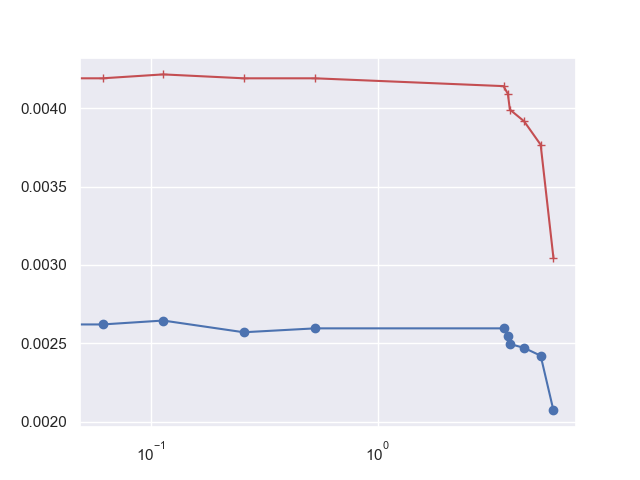

In [18]:
fig,ax = plt.subplots()
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1984['Ca+2.tot'],'r+-')
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1985['Ca+2.tot'],'bo-')
ax.set_xscale('log')

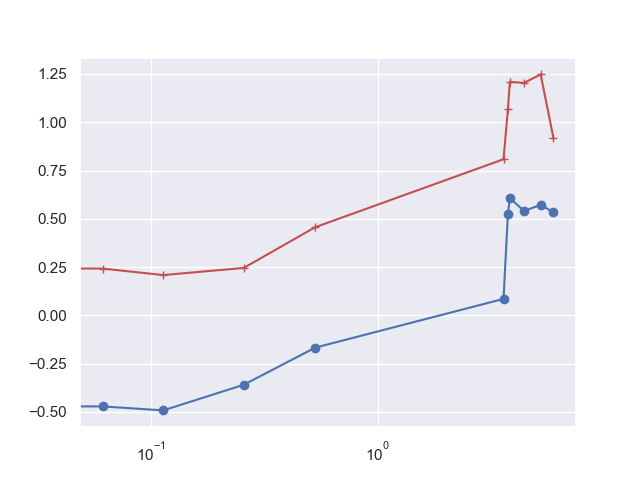

In [19]:
fig,ax = plt.subplots()
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1984['Calcite[s].si'],'r+-')
ax.plot(df_coord.loc[Res_Simulation_1984.index,'distance'], Res_Simulation_1985['Calcite[s].si'],'bo-')
ax.set_xscale('log')

In [20]:
# Run a scenario for both datasets where we bring all samples to equilibrium and then we plot the amounts of calcite preciptitated along the stream
Res_Precip_1984 = pd.DataFrame(columns=OutVars1, index=df_data_1984.index)
OrchInput_Precip_1984 = pd.DataFrame(columns=InVars1, index=df_data_1984.index)


# set default watervolume and gasvolume
IN1[0][np.where(InVars1 == 'watervolume')] = 1.0 # per liter
IN1[0][np.where(InVars1 == 'gasvolume_fixed')] = 0.0 # no gas 
IN1[0][np.where(InVars1 == 'fixed_logact_CO2')] = -3.38 # not used for this calculation
IN1[0][np.where(InVars1 == 'deltaSIcalcite')] = 0.0 # not used for this calculation

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1984.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1984.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO2.set_and_calculate(IN1)

    OrchInput_Precip_1984.loc[sample] = IN1[0]    
    Res_Precip_1984.loc[sample] = OUT[0]

table_mdini = Res_Precip_1984[Res_List].to_markdown(floatfmt='.4e')
# display(Markdown(table_mdini))
Res_Precip_1984[Res_List]

,pH,T,I,HCO3-.tot,Ca+2.tot,HCO3-.con,Ca+2.con,HCO3-.diss,Ca+2.diss,CO2[g].con,CO2[g].logact,Calcite[s].si,Calcite[s].tot
Sample,,,,,,,,,,,,,
S-1,8.009345,297.450012,0.010588,0.005048,0.004117,0.000721,0.001658,0.000776,0.002061,0.000417,-3.38,0.0,0.002056
S-3,8.009925,297.75,0.010854,0.005179,0.004192,0.00072,0.001652,0.000775,0.002061,0.000417,-3.38,0.0,0.002131
S-2,7.995012,297.850006,0.011045,0.005163,0.004217,0.000695,0.001772,0.000749,0.002213,0.000417,-3.38,0.0,0.002004
D-1,8.008001,297.450012,0.010606,0.005081,0.004192,0.000719,0.001669,0.000774,0.002074,0.000417,-3.38,-0.0,0.002118
D-3,8.00323,296.75,0.010793,0.005146,0.004192,0.000719,0.001733,0.000775,0.002154,0.000417,-3.38,-0.0,0.002038
F-1,8.011632,294.549988,0.010792,0.005113,0.004142,0.000757,0.001735,0.000815,0.002148,0.000417,-3.38,0.0,0.001994
F-3,8.015956,293.649994,0.010724,0.005097,0.004092,0.000775,0.001727,0.000834,0.002132,0.000417,-3.38,-0.0,0.00196
F-4,8.017197,292.850006,0.010851,0.004556,0.003992,0.000787,0.001746,0.000847,0.002156,0.000417,-3.38,0.0,0.001836
F-5,8.018376,292.75,0.010764,0.004474,0.003917,0.00079,0.001737,0.00085,0.002142,0.000417,-3.38,-0.0,0.001775


In [21]:
Res_Precip_1985 = pd.DataFrame(columns=OutVars1, index=df_data_1985.index)
OrchInput_Precip_1985 = pd.DataFrame(columns=InVars1, index=df_data_1985.index)

# loop over available samplesCa_Range 
# we use a counter ii in order to store the results
for sample in df_data_1985.index:
    # set InVars
    # please note InVars was initialized assuming the same frequency as
    # Lorah and Herman.

    # please note, we fill until -2, watervolume and gasvolume have already
    # been defined above. Please note we use "Orchestra" notation
    IN1[0][:-4] = df_data_1985.loc[sample, InVars1[:-4]].values
    
    # run ORCHESTRA
    OUT = pO2.set_and_calculate(IN1)

    OrchInput_Precip_1985.loc[sample] = IN1[0]    
    Res_Precip_1985.loc[sample] = OUT[0]

table_mdini = Res_Precip_1985[Res_List].to_markdown(floatfmt='.4e')
# display(Markdown(table_mdini))
Res_Precip_1985[Res_List]

,pH,T,I,HCO3-.tot,Ca+2.tot,HCO3-.con,Ca+2.con,HCO3-.diss,Ca+2.diss,CO2[g].con,CO2[g].logact,Calcite[s].si,Calcite[s].tot
Sample,,,,,,,,,,,,,
S-1,8.10036,293.149994,0.006771,0.003835,0.002545,0.000931,0.001093,0.00099,0.001266,0.000417,-3.38,0.0,0.001279
S-3,8.090287,293.149994,0.007056,0.003917,0.00262,0.000911,0.001153,0.00097,0.001342,0.000417,-3.38,0.0,0.001278
S-2,8.08542,293.149994,0.007046,0.003933,0.002645,0.000901,0.001178,0.000959,0.001372,0.000417,-3.38,-0.0,0.001273
D-1,8.093776,292.649994,0.007035,0.003884,0.00257,0.000926,0.001144,0.000985,0.001331,0.000417,-3.38,0.0,0.001239
D-3,8.093279,290.149994,0.007114,0.003884,0.002595,0.000961,0.001204,0.001022,0.001395,0.000417,-3.38,0.0,0.0012
F-1,8.092895,290.149994,0.007175,0.003851,0.002595,0.00096,0.001208,0.001022,0.001401,0.000417,-3.38,-0.0,0.001194
F-3,8.090982,289.649994,0.007244,0.003835,0.002545,0.000964,0.001232,0.001026,0.00143,0.000417,-3.38,0.0,0.001115
F-4,8.097882,286.149994,0.007362,0.003671,0.002495,0.001035,0.00128,0.001101,0.001478,0.000417,-3.38,0.0,0.001017
F-5,8.095576,286.649994,0.007345,0.003606,0.00247,0.001022,0.00128,0.001087,0.00148,0.000417,-3.38,-0.0,0.00099


Text(0, 0.5, 'Total Precipitated Calcite')

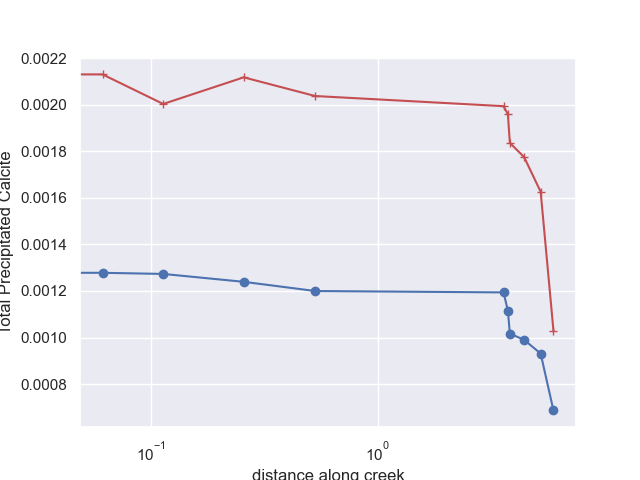

In [22]:
fig1,ax1 = plt.subplots()
ax1.plot(df_coord.loc[Res_Precip_1984.index,'distance'], Res_Precip_1984['Calcite[s].tot'],'r+-')
ax1.plot(df_coord.loc[Res_Precip_1985.index,'distance'], Res_Precip_1985['Calcite[s].tot'],'bo-')
ax1.set_xscale('log')
ax1.set_xlabel('distance along creek')
ax1.set_ylabel('Total Precipitated Calcite')

Text(0, 0.5, 'log(P_{CO_2})')

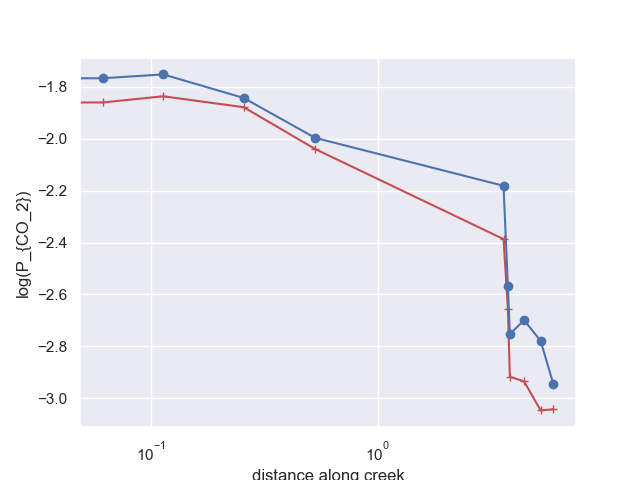

In [23]:
fig2,ax2 = plt.subplots()
ax2.plot(df_coord.loc[Res_Precip_1984.index,'distance'], Res_Simulation_1984['CO2[g].logact'],'r+-')
ax2.plot(df_coord.loc[Res_Precip_1985.index,'distance'], Res_Simulation_1985['CO2[g].logact'],'bo-')
ax2.set_xscale('log')
ax2.set_xlabel('distance along creek')
ax2.set_ylabel('log(P_{CO_2})')